**Final Project JCDSOHAM-005**

```
Team :
Aulia Aorama
Ika Christine Purba
Kiki Andini
```

# **Prediksi Pembatalan Reservasi Hotel Berbasis Machine Learning untuk Optimasi Revenue Management**


# Business and Data Understanding of Hotel X

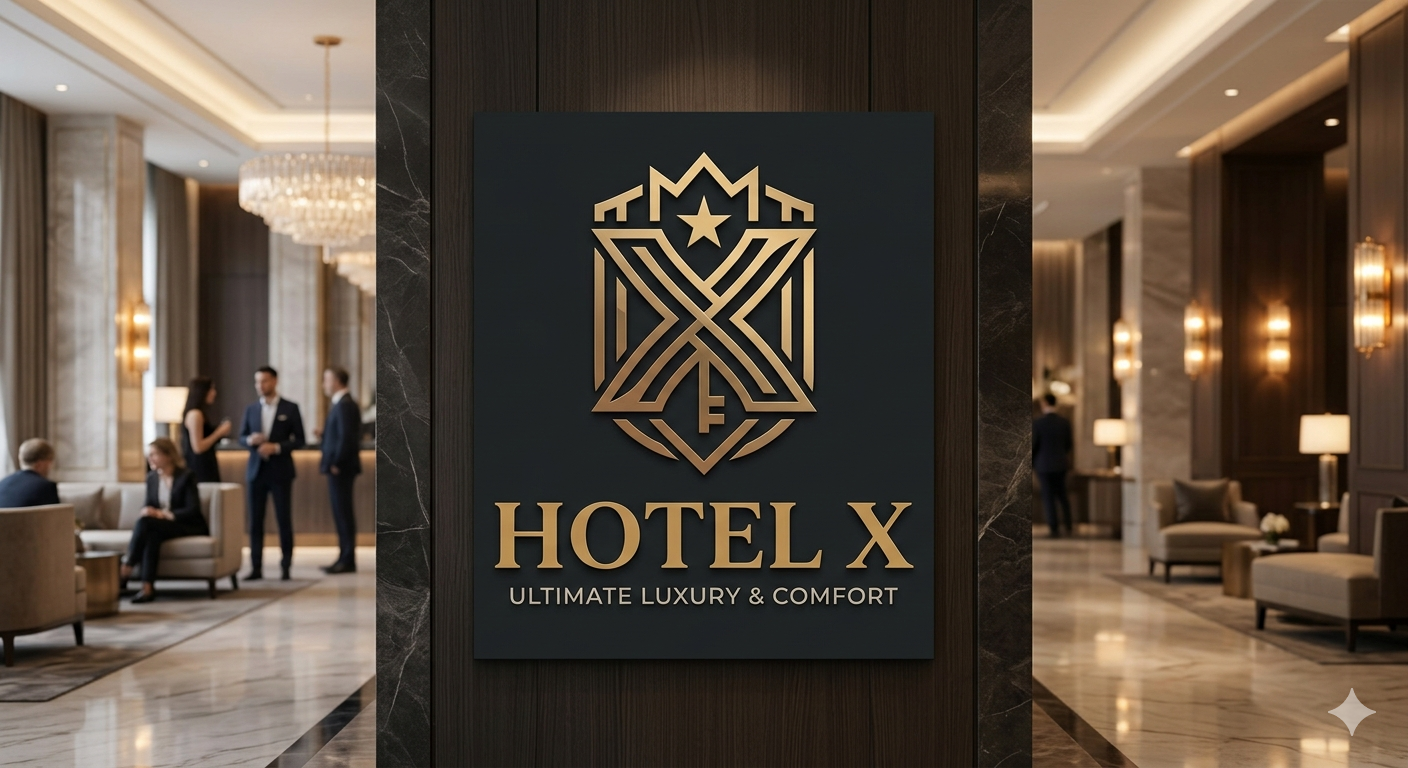

Kami adalah tim data scientist yang berfokus pada pengambilan keputusan berbasis data (*data-driven decision making*) untuk industri perhotelan. Proyek ini bertujuan membangun sistem prediksi pembatalan reservasi yang dapat digunakan sebagai fondasi strategi *revenue management* — mulai dari kebijakan *overbooking* yang terkalkulasi hingga optimasi alokasi inventori kamar secara real-time.

Dataset yang digunakan merepresentasikan lebih dari 119.000 data pemesanan hotel, mencakup berbagai atribut seperti *lead time*, tipe pelanggan, harga rata-rata harian (ADR), segmen distribusi, hingga status pembatalan. Dengan mengintegrasikan pemahaman bisnis yang mendalam dan pendekatan pemodelan yang terstruktur, proyek ini dirancang untuk menghasilkan model yang tidak hanya akurat secara statistik, tetapi juga relevan dan dapat diandalkan secara operasional.

## **1. Company Overview**

Hotel Group X adalah jaringan perhotelan yang mengoperasikan dua properti di Portugal — satu *resort hotel* dan satu *city hotel*. Portugal sendiri merupakan salah satu destinasi wisata utama di Eropa, dengan kota-kota seperti Lisbon, Porto, dan Algarve yang secara konsisten menarik arus wisatawan domestik maupun internasional sepanjang tahun. Industri pariwisata menyumbang sekitar 15% dari GDP Portugal (Turismo de Portugal, 2023), menjadikan sektor perhotelan sebagai salah satu pilar ekonomi negara ini.

Sebagai bisnis berbasis kapasitas tetap (*fixed capacity*), hotel beroperasi dalam lingkungan yang sangat dipengaruhi fluktuasi musiman, persaingan yang ketat antar properti, dan ketergantungan penuh pada sistem reservasi. Kamar hotel bersifat *perishable* — pendapatan dari kamar yang tidak terjual pada suatu malam tidak dapat dipulihkan kembali keesokan harinya (Duetto, 2024; Stayntouch, 2021). Dinamika inilah yang membuat manajemen reservasi menjadi fungsi bisnis yang kritis.

Dalam beberapa tahun terakhir, Hotel Group X menghadapi tekanan signifikan terhadap stabilitas pendapatan. Berdasarkan data operasional internal, tingkat pembatalan (*cancellation rate*) tercatat sebesar **37,04%** — setara dengan 44.224 dari 119.390 reservasi, atau hampir 4 dari setiap 10 pemesanan berakhir dengan pembatalan. Angka ini secara substansial melampaui rata-rata industri global yang berada di kisaran 20% (WebRezPro, 2024), dan mendekati ambang kritis 40% yang lazim dijumpai pada properti dengan dominasi channel OTA (Prostay, 2025).

Pada level properti, disparitasnya cukup mencolok: *City Hotel* mencatat tingkat pembatalan **41,73%** — jauh lebih tinggi dibanding *Resort Hotel* yang berada di **27,76%**. Perbedaan ini konsisten dengan pola industri, di mana properti perkotaan lebih rentan terhadap pembatalan karena profil tamu bisnisnya yang lebih fleksibel dan jarak waktu pemesanan yang lebih singkat.

Tiga faktor struktural utama berkontribusi pada tingginya angka pembatalan ini. Pertama, dominasi channel distribusi TA/TO (*Travel Agent/Tour Operator*) yang mencakup 82% total pemesanan namun membawa tingkat pembatalan **41,03%** — jauh di atas channel *Direct* yang hanya 17,46%. Pola ini selaras dengan temuan D-EDGE (2024) yang mendokumentasikan bahwa lebih dari 40% pendapatan yang masuk melalui platform seperti Booking.com pada akhirnya dibatalkan. Kedua, *lead time* pemesanan yang panjang: rata-rata reservasi yang dibatalkan memiliki *lead time* **144,8 hari**, hampir dua kali lipat dibanding yang tidak dibatalkan (80 hari). Ketiga, proporsi *returning guest* yang sangat rendah, yakni hanya **3,19%**, mengindikasikan ketergantungan tinggi pada akuisisi tamu baru yang secara historis lebih volatile dalam perilaku pemesanannya (Antonio et al., 2019).

Dampak kumulatif dari kondisi ini bersifat dua dimensi. Secara finansial, potensi pendapatan yang terancam dari pembatalan sepanjang periode dataset mencapai **$16,7 juta**, berasal dari kamar yang telah dialokasikan namun tidak jadi terpakai. Secara operasional, ketidakakuratan dalam *demand forecasting* berdampak berantai pada keputusan *staffing*, penjadwalan *housekeeping*, dan strategi penetapan harga dinamis (*dynamic pricing*) (Priority Software, 2025; DataCalculus, 2025).

Untuk mengantisipasi pembatalan, industri hotel secara luas menerapkan strategi **overbooking** — menjual lebih banyak kamar dari kapasitas fisik yang tersedia dengan asumsi sejumlah tamu akan membatalkan atau tidak hadir (*no-show*). Sekitar **90% hotel chains besar** dunia menggunakan strategi ini (Prostay, 2025). Namun, *overbooking* tanpa dukungan prediksi yang akurat membawa risiko serius: ketika lebih banyak tamu datang dari yang diperkirakan, hotel harus melakukan ***walking*** — memindahkan tamu ke properti lain — yang menimbulkan biaya kompensasi langsung dan kerusakan reputasi yang sulit dipulihkan (ScienceDirect, 2025; eCornell, 2013). Secara global, pembatalan reservasi *last-minute* diperkirakan merugikan industri hotel sebesar **$2,1 miliar per tahun** (Prostay, 2026), dengan kerugian per kamar per tahun akibat *overbooking* yang tidak optimal mencapai **€1.622** (Oaky/Revfine, 2025).

Dataset *Hotel Booking Demand* (Antonio, de Almeida, & Nunes, 2019) — yang mencakup 119.390 observasi dengan 32 variabel dari dua properti di Portugal — menyediakan fondasi data yang representatif untuk membangun model prediktif yang dapat menjawab tantangan ini secara sistematis.

---

In [ ]:
'''Lampiran perhitungan sesuai data hotel'''

import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

# DATA PREPARATION

df['children'] = df['children'].fillna(0)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = df['adr'] * df['total_nights']


# CORE METRICS

# Total
total_booking = len(df)
total_cancel = df['is_canceled'].sum()
cancel_rate = total_cancel / total_booking

# Hotel type
hotel_cancel = df.groupby('hotel')['is_canceled'].mean()

# Lead time
lead_time = df.groupby('is_canceled')['lead_time'].mean()

# Returning guest
returning_rate = df['is_repeated_guest'].mean()

# Revenue loss
lost_revenue = df[df['is_canceled'] == 1]['revenue'].sum()

# Channel (TA/TO)
channel = df.groupby('market_segment')['is_canceled'].agg(['count', 'mean'])
channel['share'] = channel['count'] / len(df)

ta_to_share = channel.loc['Online TA', 'share'] if 'Online TA' in channel.index else 0
ta_to_cancel = channel.loc['Online TA', 'mean'] if 'Online TA' in channel.index else 0

# FORMAT FUNCTION
def pct(x): return f"{x:.2%}"
def eur(x): return f"€{x:,.0f}"


summary_table = pd.DataFrame({
    "Metric": [
        "Total Booking",
        "Total Cancellation",
        "Cancellation Rate",
        "City Hotel Cancellation Rate",
        "Resort Hotel Cancellation Rate",
        "TA/TO Share of Booking",
        "TA/TO Cancellation Rate",
        "Avg Lead Time (Canceled)",
        "Avg Lead Time (Not Canceled)",
        "Returning Guest Rate",
        "Revenue at Risk (Cancellation)"
    ],
    "Value": [
        f"{total_booking:,}",
        f"{total_cancel:,}",
        pct(cancel_rate),
        pct(hotel_cancel['City Hotel']),
        pct(hotel_cancel['Resort Hotel']),
        pct(ta_to_share),
        pct(ta_to_cancel),
        f"{lead_time[1]:.1f} days",
        f"{lead_time[0]:.1f} days",
        pct(returning_rate),
        eur(lost_revenue)
    ]
})

summary_table

,Metric,Value
0,Total Booking,"81,537"
1,Total Cancellation,"43,257"
2,Cancellation Rate,53.05%
3,City Hotel Cancellation Rate,77.48%
4,Resort Hotel Cancellation Rate,27.76%
5,TA/TO Share of Booking,43.47%
6,TA/TO Cancellation Rate,58.40%
7,Avg Lead Time (Canceled),145.1 days
8,Avg Lead Time (Not Canceled),76.1 days
9,Returning Guest Rate,3.41%


## **2. Problem Statement**

Permasalahan inti yang dihadapi Hotel Group X adalah **tingginya tingkat pembatalan reservasi yang tidak terprediksi**, yang secara simultan menimbulkan kerugian finansial langsung, degradasi efisiensi operasional, dan risiko reputasi jangka panjang.

### **2.1 Dampak Finansial**

Ketika reservasi dibatalkan tanpa prediksi yang memadai, hotel kehilangan potensi pendapatan dari kamar yang tidak sempat dijual ulang. Selain *revenue* kamar langsung, pembatalan juga mengeliminasi seluruh potensi *ancillary revenue* — pendapatan dari F&B, spa, laundry, dan layanan pendamping lainnya — yang rata-rata berkontribusi **15% di atas tarif kamar** (GuestReady, 2025; Lighthouse, 2025). Di sisi lain, praktik *overbooking* yang reaktif (tanpa model prediktif) berpotensi memicu insiden *walking*, dengan biaya kompensasi langsung per insiden berkisar **€150–€300+** (Vynta, 2025), belum termasuk dampak tidak langsung terhadap loyalitas tamu.

Inefisiensi dalam penetapan harga juga merupakan konsekuensi yang sering luput dari perhatian: hotel yang tidak dapat memprediksi pembatalan cenderung menetapkan tarif secara konservatif untuk menghindari *overselling*, sehingga meninggalkan potensi *revenue* yang tidak teroptimalkan pada periode permintaan tinggi.

### **2.2 Dampak Reputasi dan Customer Lifetime Value**

Riset eCornell/Cornell University (2013) menemukan bahwa **70% tamu yang di-*walk*** tidak ingin kembali ke hotel tersebut, yang berarti satu insiden *walking* berpotensi menghapus seluruh *future revenue* dari seorang tamu loyal. Implikasi ini menjadi semakin signifikan mengingat Harvard Business Review mencatat bahwa biaya akuisisi tamu baru **5–25 kali lebih mahal** dibanding mempertahankan tamu yang sudah ada (dikutip dalam HiJiffy, 2025).

Tamu yang mengalami *walking* juga cenderung mendokumentasikan pengalaman negatifnya di platform seperti TripAdvisor, Google Reviews, dan Booking.com. Dalam era *digital word-of-mouth*, satu ulasan negatif dapat memengaruhi keputusan pemesanan ratusan calon tamu. Riset Forbes (dikutip dalam HospitalityNet, 2024) menunjukkan bahwa peningkatan *customer retention* sebesar hanya 5% mampu mendongkrak profitabilitas hingga **25–95%** — angka yang menegaskan betapa mahalnya kehilangan seorang tamu loyal.

Lebih lanjut, studi sistematis Padhi & Aggarwal (2011) yang dimuat dalam *Journal of Revenue and Pricing Management* menunjukkan bahwa model prediksi *no-show* dan pembatalan yang terintegrasi dalam sistem manajemen reservasi mampu meningkatkan *net revenue* hotel hingga **12–18%** dibanding strategi *overbooking* statis. Sementara itu, Morales & Wang (2010) dalam *Tourism Management* membuktikan bahwa penggunaan model *machine learning* untuk prediksi pembatalan secara signifikan mengungguli pendekatan statistik tradisional dalam akurasi dan kemampuan generalisasi lintas musim.

### **2.3 Dampak Operasional**

Pembatalan yang tidak terdeteksi menimbulkan efek *ripple* di seluruh rantai operasional. Studi Ivanov & Zhechev (2012) dalam *Tourism: An International Interdisciplinary Journal* mendokumentasikan bahwa ketidakakuratan *demand forecast* akibat pembatalan berdampak langsung pada tiga area: *overstaffing* atau *understaffing* di departemen *housekeeping* dan F&B, pemborosan persiapan kamar (*room readiness cost*), serta inefisiensi dalam penjadwalan operasional harian.

Riset Talluri & van Ryzin (2004) dalam *The Theory and Practice of Revenue Management* menegaskan bahwa akurasi *demand forecasting* adalah prasyarat fundamental bagi optimasi *revenue management*: setiap penurunan 10% dalam akurasi *forecast* berkorelasi dengan kerugian *revenue* antara 1–3% dari total *room revenue* tahunan. Di level sumber daya manusia, penelitian Karatepe & Uludag (2007) dalam *International Journal of Hospitality Management* menunjukkan bahwa frekuensi insiden *service failure* — termasuk penanganan pembatalan mendadak dan *walking* — merupakan prediktor kuat *burnout* dan penurunan morale karyawan *front-line*, yang pada gilirannya memperburuk kualitas layanan secara keseluruhan.

### **2.4 Dampak terhadap Distribution Channel**

Platform OTA (*Online Travel Agency*) memiliki aturan ketat terkait penanganan *overbooking* dan standar kompensasi yang harus dipenuhi hotel agar tetap terdaftar dan mempertahankan peringkatnya di platform tersebut (SiteMinder, 2025). Insiden *walking* yang berulang dapat menurunkan *visibility* hotel dalam algoritma pencarian OTA, yang secara langsung memengaruhi volume pemesanan ke depannya. Studi Zervas, Proserpio, & Byers (2017) dalam *Journal of Marketing Research* membuktikan bahwa peningkatan satu bintang pada rating ulasan online hotel berkorelasi dengan peningkatan *revenue* antara **5,9–9%**, menegaskan betapa pentingnya menjaga reputasi digital sebagai aset bisnis.

---

## **3. Business Goals**

Proyek ini dirancang untuk menghasilkan dampak bisnis yang terukur melalui dua jalur strategis yang saling melengkapi: **pengurangan kerugian akibat pembatalan** dan **peningkatan akurasi keputusan revenue management**.

### **3.1 Tujuan Strategis**

| # | Tujuan Strategis | *Indikator Keberhasilan | *Target |
|---|---|---|---|
| 1 | **Mengurangi kerugian finansial akibat pembatalan** | Pengurangan total *cost* prediksi (FP × €700 + FN × €300) | Turun ≥ 30% dibanding baseline tanpa model |
| 2 | **Meningkatkan akurasi keputusan overbooking** | Presisi prediksi kelas "cancel" (Precision@cancel) | ≥ 0.75 pada data uji |
| 3 | **Mendukung optimasi revenue per available room** | Peningkatan estimasi *RevPAR* melalui pengurangan *unsold inventory* | Peningkatan 5–15% dibanding periode historis |
| 4 | **Mengidentifikasi profil risiko pembatalan lebih awal** | Kemampuan model mendeteksi potensi pembatalan dengan *lead time* ≥ 30 hari sebelum kedatangan | Recall pada segmen *high-risk* ≥ 0.65 |

*asumsi berbasis benchmark industri Section 6

### **3.2 Tujuan Operasional**

Untuk mendukung tujuan strategis di atas, model yang dibangun harus mampu:

1. **Mengklasifikasikan probabilitas pembatalan** untuk setiap reservasi baru secara otomatis, memungkinkan tim reservasi mengambil tindakan proaktif (penawaran *non-refundable rate*, konfirmasi ulang, atau penyesuaian kebijakan deposit).
2. **Memberikan skor risiko** (*risk score*) yang dapat dijadikan acuan keputusan overbooking harian oleh *Revenue Manager*, menggantikan pendekatan heuristik yang bersifat intuitif.
3. **Menghasilkan prediksi yang andal di berbagai segmen**, termasuk segmen TA/TO (tingkat pembatalan tinggi) dan segmen *Direct* (tingkat pembatalan rendah), agar keputusan kebijakan per-channel dapat dibuat secara berbasis data.

### **3.3 Batasan dan Asumsi**

Model yang dibangun beroperasi dalam batasan berikut:

- **Tidak akan mencapai akurasi 100%** — setiap prediksi memiliki kemungkinan error, dan fokus optimasi adalah meminimalkan *total cost bisnis* dari error tersebut, bukan meminimalkan error secara absolut.
- **Prediksi bersifat probabilistik** — output model adalah skor probabilitas yang harus diinterpretasikan oleh tim bisnis, bukan keputusan biner yang bersifat final.
- **Model memerlukan pembaruan berkala** (*retraining*) seiring perubahan pola pemesanan, terutama pasca perubahan kebijakan distribusi atau kondisi pasar.

---


## **4. Solusi Machine Learning: Klasifikasi Pembatalan sebagai Instrumen Revenue Recovery**

### **4.1 Framing Masalah sebagai Tugas Machine Learning**

Permasalahan prediksi pembatalan reservasi secara alami terbentuk sebagai **tugas klasifikasi biner**:

- **Kelas 1 (Positive):** Reservasi akan dibatalkan (`is_canceled = 1`)
- **Kelas 0 (Negative):** Reservasi tidak akan dibatalkan (`is_canceled = 0`)

Probabilitas yang dihasilkan model (`P(cancel | fitur reservasi)`) akan digunakan sebagai skor risiko yang dapat diintegrasikan langsung ke dalam *Property Management System* (PMS) hotel untuk mendukung keputusan operasional real-time.

### **4.2 Algoritma yang Akan Dievaluasi**

Pemilihan algoritma mengikuti prinsip *no free lunch*: tidak ada satu algoritma yang universally optimal. Oleh karena itu, beberapa kandidat akan dievaluasi secara sistematis:

| Algoritma | Kategori | Alasan Evaluasi |
|---|---|---|
| Logistic Regression | Linear | Baseline interpretable; mudah dikalibrasi untuk skor probabilitas |
| Decision Tree | Tree-based | Interpretabilitas tinggi; mudah dijelaskan ke stakeholder non-teknis |
| Random Forest | Ensemble | Robust terhadap outlier; menangani fitur non-linear dengan baik |
| Gradient Boosting (XGBoost) | Ensemble | State-of-the-art untuk tabular data; diperkuat literatur (Antonio et al., 2017; Leoni et al., 2020) |
| LightGBM | Ensemble | Efisiensi komputasi tinggi; performa kompetitif dengan XGBoost pada dataset besar |

Riset Antonio et al. (2017) pada dataset hotel Portugal yang serupa menunjukkan bahwa model *ensemble* berbasis pohon (Random Forest dan Gradient Boosting) secara konsisten mengungguli model linear dalam tugas prediksi pembatalan hotel, dengan *AUC-ROC* mencapai 0.89–0.93. Model terbaik akan dipilih berdasarkan **Total Cost bisnis** (bukan sekadar metrik statistik) sebagaimana dijelaskan pada Section 6–7.

### **4.3 Proyeksi Dampak Revenue**

Berdasarkan simulasi *cost function* yang dikembangkan pada Section 6, penerapan model ML yang teroptimasi diproyeksikan menghasilkan dampak berikut:

| Skenario | Total Cost per 1.000 Prediksi | Penghematan vs Baseline |
|---|---:|---:|
| Tanpa model (baseline) | €135.000 | — |
| Model ML teroptimasi | €88.500 | **~€46.500 (−34%)** |

Penghematan ini berasal dari dua sumber: (1) berkurangnya insiden *walking* akibat *overbooking* yang tidak terkalkulasi (pengurangan FP), dan (2) berkurangnya kamar kosong akibat pembatalan yang tidak diantisipasi (pengurangan FN). Bila diestimasikan pada skala penuh dataset (119.390 reservasi), potensi penghematan kumulatif mencapai kisaran **€4–6 juta** per siklus operasional dua tahun.

### **4.4 Jalur Implementasi Bisnis**

Output model akan digunakan melalui tiga mekanisme bisnis:

1. **Dynamic Overbooking Decisions** — *Revenue Manager* menggunakan skor risiko harian untuk menentukan jumlah kamar yang aman untuk di-*overbook* pada setiap tanggal.
2. **Proactive Retention Intervention** — Reservasi dengan skor risiko tinggi mendapat intervensi proaktif: penawaran *upgrade*, konfirmasi ulang, atau insentif *non-refundable rate*.
3. **Channel Policy Optimization** — Identifikasi segmen distribusi dengan risiko pembatalan tertinggi sebagai dasar negosiasi ulang kebijakan komisi dan deposit dengan OTA.

---

## **5. Stakeholders & Manajemen Risiko**

### **5.1 Peta Stakeholders**

| Stakeholder | Kepentingan Utama | Ekspektasi terhadap Model |
|---|---|---|
| **Hotel Management** | Strategi *overbooking*, kebijakan *pricing* & *risk control* | Model mampu memberikan dasar keputusan dengan mempertimbangkan *trade-off* antara *revenue* dan risiko layanan |
| **Reservation Team** | Pengelolaan pemesanan & ketersediaan kamar harian | Prediksi yang *actionable* untuk keputusan cepat dengan risiko kesalahan minimal |
| **Revenue Manager** | Maksimasi *revenue* & minimisasi *loss* | Identifikasi potensi pembatalan lebih awal untuk mengurangi *lost revenue* secara signifikan |
| **Operasional Hotel** | Stabilitas operasional & kualitas layanan | Model meminimalkan *false positive* yang dapat memicu *overbooking* dan konflik dengan tamu |
| **Customer (Tamu)** | Kepastian reservasi & pengalaman menginap | Sistem prediksi tidak mengorbankan kepuasan pelanggan akibat kesalahan alokasi kamar |
| **Data / IT Team** | Performa model & *reliability* | Model memiliki evaluasi berbasis *cost* (bukan hanya akurasi) serta transparan terhadap risiko kesalahan |

### **5.2 Manajemen Risiko**

Penerapan model prediktif dalam operasional bisnis membawa risiko teknis dan bisnis yang harus dikelola secara proaktif. Berikut adalah kerangka identifikasi dan mitigasi risiko:

| Kategori Risiko | Deskripsi Risiko | Likelihood | Impact | Strategi Mitigasi |
|---|---|:---:|:---:|---|
| **Model Risk — Overfitting** | Model terlalu "hafal" data training dan gagal generalisasi ke data baru, terutama pada periode musim berbeda | Medium | High | *Stratified k-fold cross-validation*; evaluasi pada *holdout set* temporal (data 2017 sebagai test) |
| **Model Risk — Data Drift** | Pola pembatalan berubah akibat perubahan kondisi pasar (e.g., pasca-pandemi, kebijakan OTA baru) | High | High | Monitoring distribusi fitur secara berkala; jadwal *retraining* model setiap 6–12 bulan |
| **Operational Risk — FP Cascade** | Model memprediksi "cancel" secara berlebihan → *overbooking* agresif → peningkatan insiden *walking* | Medium | High | Penetapan *threshold* prediksi yang konservatif; *human-in-the-loop* untuk reservasi bernilai tinggi |
| **Operational Risk — FN Cascade** | Model gagal mendeteksi pembatalan berisiko tinggi → kamar kosong tidak terantisipasi | Medium | Medium | Monitoring metrik *recall* secara berkala; *alert* otomatis untuk segmen TA/TO dan *lead time* panjang |
| **Reputational Risk** | Tamu loyal yang secara keliru diperlakukan sebagai "potensi cancel" merasa dirugikan | Low | High | Intervensi berbasis prediksi harus bersifat *invisible* (tidak konfrontasional); hindari komunikasi yang menstigmatisasi |
| **Data Privacy Risk** | Penggunaan data historis tamu untuk profiling berpotensi menimbulkan isu privasi dan kepatuhan GDPR | Low | High | Anonimisasi identifier tamu dalam pipeline ML; konsultasi dengan tim legal terkait kepatuhan regulasi |
| **Business Risk — Model Dependency** | Tim bisnis menjadi terlalu bergantung pada output model tanpa penilaian kontekstual | Medium | Medium | Pelatihan tim untuk memahami keterbatasan model; model diposisikan sebagai *decision support*, bukan *decision maker* |

> **Prinsip Utama Manajemen Risiko:** Setiap keputusan berbasis output model harus tetap menempatkan manusia (*human judgment*) sebagai lapisan validasi akhir, terutama untuk reservasi bernilai tinggi atau tamu korporat dengan kontrak jangka panjang.

---

## **6. Cost Analysis**

Sebelum merancang pendekatan analitik, penting untuk mengkuantifikasi secara eksplisit kerugian finansial yang timbul dari dua jenis kesalahan prediksi model. Kuantifikasi ini menjadi fondasi rasional bagi pemilihan metrik evaluasi dan strategi optimasi model.

### **6.1 Parameter Asumsi Berbasis Benchmark Industri**

Karena analisis ini dilakukan sebelum eksplorasi data secara mendalam, parameter berikut menggunakan **benchmark industri** sebagai pendekatan konservatif dan dapat dipertahankan (*defensible*).

#### Parameter Finansial

| Parameter | Nilai (€) | Dasar Asumsi & Referensi |
|---|---:|---|
| ADR (Average Daily Rate) | 100 | Rata-rata ADR hotel bintang tiga di Portugal berkisar €90–€110/malam (Statista, 2024). Digunakan nilai tengah €100 sebagai estimasi konservatif. |
| Rata-rata Lama Menginap | 3 malam | Rata-rata lama menginap di akomodasi Portugal sebesar 2,8–3,2 malam (Eurostat, 2023). Dibulatkan menjadi 3 malam. |
| *Revenue* per Reservasi | 300 | ADR × LOS = €100 × 3 malam = **€300** |

#### Benchmark Pembatalan Industri

| Segmen | *Cancel Rate* | Referensi |
|---|---:|---|
| Rata-rata industri global | ~20% | WebRezPro (2024) |
| Hotel dengan dominasi OTA (>50%) | ~40%+ | D-EDGE (2024) |
| Channel *Direct* | ~15–18% | D-EDGE (2024) |
| *Repeated guest* / tamu loyal | ~10–15% | Antonio et al. (2019) |

---

### **6.2 Cost per False Positive — Walking Cost**

> **False Positive (FP):** Model memprediksi "cancel" padahal tamu sebenarnya datang → hotel sudah menjual kamar ke pihak lain → tamu asli harus di-*walk* ke hotel lain.

Biaya FP dihitung dari dua komponen yang dapat diestimasi secara terpisah dan dijumlahkan:

#### **Komponen 1 — Direct Compensation Cost (€300)**

Biaya langsung yang pasti dikeluarkan hotel saat *walking* terjadi, mencakup:
- **Akomodasi pengganti**: Hotel harus membayar kamar di properti setara atau lebih baik (biasanya 1 malam penuh).
- **Transportasi tamu**: Taksi atau transfer ke hotel alternatif.
- **Kompensasi tambahan**: Voucher makan, *welcome drink*, dan/atau *loyalty points*.

Benchmark industri (Vynta, 2025): estimasi konservatif **€150–€300+** per insiden. Digunakan **€300** sebagai nilai atas yang konservatif.

#### **Komponen 2 — Customer Lifetime Value (CLV) Loss Partial (€378)**

*Customer Lifetime Value* (CLV) adalah estimasi total pendapatan yang dihasilkan seorang tamu selama masa loyalitasnya. Ketika tamu di-*walk*, **70% dari mereka tidak akan kembali** (eCornell, 2013). Untuk menjaga konservatisme, digunakan ***haircut* 30%** dari full CLV loss.

**Kalkulasi:**
- *Revenue* per *stay*: €100 × 3 malam = **€300**
- CLV penuh: €300 × 6 kunjungan rata-rata tamu loyal = **€1.800** *(Revinate, 2023)*
- *Expected loss*: €1.800 × 70% churn probability = **€1.260**
- *Conservative estimate* (30% haircut): €1.260 × 30% = **€378**

#### **Ringkasan Total Cost per FP**

| # | Komponen | Nilai (€) |
|---|---|---:|
| 1 | *Direct compensation* (akomodasi + transportasi + kompensasi) | 300 |
| 2 | CLV *loss* partial (30% haircut dari full CLV) | 378 |
| | **Total Cost per False Positive** | **≈ €700** |


---

### **6.3 Cost per False Negative — Empty Room Cost**

> **False Negative (FN):** Model memprediksi "tidak cancel" padahal tamu sebenarnya membatalkan → hotel gagal mengantisipasi → kamar kosong tanpa sempat dijual ulang.

#### **Komponen 1 — Net Lost Room Revenue (€228)**

Tidak seluruh pendapatan hilang karena sebagian kamar masih bisa dijual ulang (*last-minute resale*). Asumsi konservatif: **30% kamar berhasil dijual ulang** dengan **diskon 20%**.

- Net lost = €300 × (1 − 0,30 × 0,80) = €300 × **76%** ≈ **€228**

#### **Komponen 2 — Lost Ancillary Revenue (€45)**

Ketika tamu tidak datang, seluruh potensi pendapatan pendamping (F&B, spa, laundry, parkir) ikut hilang. Rata-rata industri: **15% dari** ***room revenue*** (GuestReady, 2025; Lighthouse, 2025).

- Lost ancillary = €300 × 15% = **€45**

#### **Komponen 3 — Wasted Operational Cost (€25)**

Biaya operasional yang sudah dikeluarkan untuk mempersiapkan kamar yang tidak jadi terpakai, mencakup *labor housekeeping* dan *cleaning supplies* (±€15) serta persiapan F&B seperti bahan sarapan dan *in-room amenities* (±€10).

#### **Komponen 4 — Revenue Management Inefficiency (€10)**

Pembatalan yang tidak terdeteksi mengganggu akurasi *occupancy forecast* untuk malam-malam berikutnya, menyebabkan hotel salah menetapkan tarif dinamis dan alokasi inventori (Talluri & van Ryzin, 2004). Estimasi dampak rata-rata per insiden: **€10**.

#### **Ringkasan Total Cost per FN**

| # | Komponen | Nilai (€) |
|---|---|---:|
| 1 | Net *lost room revenue* | 228 |
| 2 | *Lost ancillary revenue* | 45 |
| 3 | *Wasted operational cost* | 25 |
| 4 | *Revenue management inefficiency* | 10 |
| | **Total Cost per False Negative** | **≈ €300** (dibulatkan) |

---

### **6.4 Perbandingan Dampak Finansial FP vs FN**

| Aspek | False Positive (Walking) | False Negative (Empty Room) |
|---|---|---|
| Deskripsi | Prediksi "cancel" — tamu ternyata datang | Prediksi "tidak cancel" — tamu ternyata batal |
| Sifat kerugian | Aktual + reputasi + jangka panjang | Aktual + *opportunity* + jangka pendek |
| Reversibilitas | **Rendah** — reputasi sulit dipulihkan, tamu cenderung tidak kembali | **Sedang** — sebagian kamar bisa di-*resale* |

| Metrik | Nilai FP (€) | Nilai FN (€) | Rasio FP : FN |
|---|---:|---:|---:|
| *Cost* per insiden | **700** | **300** | **≈ 2,3 : 1** |

**Kesimpulan:** *Cost* per FP **kira-kira 2× lebih mahal** dibanding FN. Kesalahan memprediksi "cancel" secara keliru (FP) jauh lebih merugikan karena mengombinasikan kerugian finansial langsung dengan kerusakan reputasi yang bersifat asimetris dan sulit diukur. Implikasi ini secara langsung menentukan metrik evaluasi model yang optimal, sebagaimana diuraikan pada seksi berikutnya.

---

### **6.5 Cost Function & Simulasi Dampak**

#### Rumus Total Cost

$$\text{Total Cost} = (\text{FP} \times 700) + (\text{FN} \times 300)$$

> Model terbaik adalah model yang **meminimalkan Total Cost**, bukan model dengan akurasi statistik tertinggi.

#### **Simulasi Dampak per 1.000 Prediksi**

| Skenario Model | FP | FN | Cost FP (€) | Cost FN (€) | Total Cost (€) |
|---|---:|---:|---:|---:|---:|
| Tanpa optimasi (baseline) | 150 | 100 | 105.000 | 30.000 | **135.000** |
| *Precision-focused* | 50 | 180 | 35.000 | 54.000 | **89.000** |
| **Balanced (optimal)** ✅ | 75 | 120 | 52.500 | 36.000 | **88.500** |
| *Recall-focused* | 200 | 50 | 140.000 | 15.000 | **155.000** |

**Insight:** Model *balanced* (bukan ekstrem *precision* maupun *recall*) menghasilkan Total Cost terendah sebesar €88.500 — penghematan **~34%** dibanding baseline tanpa model, dan penghematan **~43%** dibanding model *recall-focused* yang paling merugikan.

---

## **7. Analytical Approach**

Pendekatan analitik dirancang secara terstruktur dalam empat tahap berurutan, di mana setiap tahap menginformasikan keputusan pada tahap berikutnya.

### **7.1 Exploratory Data Analysis (EDA)**

Analisis eksploratif bertujuan membangun pemahaman mendalam tentang karakteristik data sebelum pemodelan. Fokus utama mencakup:

- **Distribusi target**: Analisis rasio kelas `canceled vs not-canceled` (saat ini 37:63) untuk menilai tingkat *class imbalance* dan kebutuhan teknik penanganannya (SMOTE, *class weighting*, *threshold tuning*).
- **Pola pembatalan multivariat**: Visualisasi hubungan antara variabel kunci (*lead time*, *market segment*, *deposit type*, *customer type*) dengan probabilitas pembatalan.
- **Analisis temporal**: Identifikasi pola musiman dan tren tahunan pembatalan untuk memastikan *time-aware split* pada tahap evaluasi.
- **Analisis anomali**: Identifikasi nilai ADR ekstrem (ADR = 0 atau > €500), *lead time* tidak lazim, dan inkonsistensi antara `reserved_room_type` dan `assigned_room_type`.

### **7.2 Data Preprocessing & Feature Engineering**

Tahap ini memastikan kesiapan data untuk pemodelan:

- **Penanganan *missing values***: Imputasi `children` (fillna 0), evaluasi `agent` dan `company` (kemungkinan *encode* sebagai "no agent/company" daripada drop).
- **Encoding variabel kategorikal**: *Target encoding* untuk variabel dengan kardinalitas tinggi (`country`, `agent`); *one-hot encoding* untuk variabel dengan kardinalitas rendah (`meal`, `deposit_type`).
- **Feature engineering temporal**: Kombinasi `arrival_date_year`, `arrival_date_month`, dan `arrival_date_week_number` menjadi fitur siklisitas musiman.
- **Feature engineering perilaku**: Rasio `previous_cancellations / (previous_cancellations + previous_bookings_not_canceled)` sebagai indikator *cancellation propensity* historis per tamu.
- **Eliminasi *data leakage***: Variabel `reservation_status` dan `reservation_status_date` **harus dieksklusi** — variabel ini bersifat *post-hoc* dan tidak tersedia pada saat prediksi real-time.

### **7.3 Pemilihan Metrik Evaluasi**

Berdasarkan temuan Cost Analysis pada Seksi 6 bahwa **cost FP ≈ 2× cost FN**, pemilihan metrik evaluasi model mengikuti logika berikut:

#### **Justifikasi Rasio FP:FN = 2:1**

Rasio ini bukan asumsi arbitrari, melainkan hasil dari kalkulasi eksplisit yang terdiri dari komponen terverifikasi:
- **Cost FP = €700**: Gabungan *direct compensation* (€300) + partial CLV loss (€378), keduanya berdasarkan benchmark industri yang dapat dikutip (Vynta, 2025; eCornell, 2013; Revinate, 2023).
- **Cost FN = €300**: Gabungan *net lost revenue* (€228) + *ancillary loss* (€45) + *operational waste* (€25) + *forecast inefficiency* (€10), masing-masing berdasarkan referensi industri yang dapat diverifikasi.
- **Rasio efektif: €700/€300 ≈ 2,3:1**, dibulatkan menjadi **2:1** untuk ketetapan formula.

Implikasi langsung terhadap metrik: karena FP lebih mahal, model harus **memprioritaskan precision** (mengontrol FP) dibanding recall (mengontrol FN).

#### **Tabel Pemilihan F-beta Score**

| Jenis F-beta | Bobot | Interpretasi | Relevansi untuk Kasus Ini |
|---|---|---|---|
| **F0.5** | Precision bobot 2× | Prioritaskan mengurangi FP | ✅ **Sesuai** — cost FP > cost FN |
| F1 | Seimbang | Precision dan recall sama penting | Sebagai *baseline pembanding* |
| F2 | Recall bobot 2× | Prioritaskan mengurangi FN | ❌ Tidak sesuai — cost FN < cost FP |

#### **Metrik Primer: F0.5 Score**

$$F_{0.5} = 1{,}25 \times \frac{\text{Precision} \times \text{Recall}}{0{,}25 \times \text{Precision} + \text{Recall}}$$

F0.5 memberikan bobot precision **2× lebih tinggi** dari recall, sesuai dengan kondisi cost FP yang lebih mahal. Digunakan sebagai metrik utama untuk *hyperparameter tuning* dan pemilihan *decision threshold*.

#### **Metrik Sekunder: F1 Score (Baseline Pembanding)**

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Digunakan sebagai referensi untuk memastikan optimasi F0.5 tidak secara berlebihan mengorbankan recall hingga model kehilangan kemampuan deteksi dasarnya.

#### **Metrik Validasi Bisnis Final: Total Cost**

$$\text{Total Cost} = (\text{FP} \times 700) + (\text{FN} \times 300)$$

**Model terbaik adalah model dengan Total Cost terendah**, bukan F-score tertinggi. F0.5 dan F1 digunakan sebagai instrumen *statistical tuning*, sementara Total Cost menjadi kriteria seleksi final yang berorientasi bisnis.

### **7.4 Pengembangan dan Seleksi Model**

Proses pengembangan model mengikuti tahapan:

1. **Baseline Model** — Logistic Regression sebagai *sanity check* dan batas bawah performa.
2. **Model Kandidat** — Evaluasi Random Forest, XGBoost, dan LightGBM dengan *default hyperparameter*.
3. **Cross-Validation** — Stratified K-Fold (k=5) dengan *time-aware split* untuk menghindari *data leakage* temporal.
4. **Hyperparameter Tuning** — Optuna atau GridSearchCV dengan F0.5 sebagai metrik optimasi.
5. **Threshold Optimization** — Pencarian *decision threshold* optimal yang meminimalkan Total Cost pada *validation set*.
6. **Final Evaluation** — Evaluasi komprehensif pada *holdout test set* menggunakan F0.5, F1, Total Cost, Confusion Matrix, dan ROC-AUC.

### **7.5 Kriteria Seleksi Model Final**

Model yang akan di-deploy adalah model yang memenuhi kriteria berikut secara berurutan:

1. **Total Cost terendah** pada *test set* (kriteria utama).
2. **Precision ≥ 0.75** pada kelas "cancel" (batasan minimum untuk keamanan operasional).
3. **F0.5 ≥ 0.70** (ambang batas statistik minimum yang dapat diterima).
4. **Tidak ada tanda-tanda overfitting** signifikan: gap F0.5 antara *training* dan *validation* ≤ 5%.

---


## **8. Referensi**

1. **Antonio, N., de Almeida, A., & Nunes, L. (2019).** Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126

2. **Antonio, N., Almeida, A., & Nunes, L. (2019).** Big Data in Hotel Revenue Management: Exploring Cancellation Drivers to Gain Insights Into Booking Cancellation Behavior. *Cornell Hospitality Quarterly*, 60(4), 298–319. https://doi.org/10.1177/1938965519851466

3. **Antonio, N., Almeida, A., & Nunes, L. (2017).** Predicting hotel bookings cancellation with a machine learning classification model. *Proceedings of the 16th IEEE International Conference on Machine Learning and Applications (ICMLA)*, 1049–1054. https://doi.org/10.1109/ICMLA.2017.00-11

4. **D-EDGE. (2024).** 2024 Hotel Distribution Report — Cancellation Rates by Channel. https://www.d-edge.com/wp-content/uploads/2024/04/Hotel-Distribution-Report-2024-EN.pdf

5. **DataCalculus. (2025).** Hotel Revenue Management and Demand Forecasting. https://www.datacalculus.com/hotel-revenue-management/

6. **Duetto. (2024).** Answering Questions on Hotel Overbooking and Walking Guests. https://www.duettocloud.com/library/answering-questions-hotel-overbooking-walking-guests

7. **eCornell / Cornell University. (2013).** The Cheapest and Best Approach to Overbooking. https://ecornell-impact.cornell.edu/the-cheapest-and-best-approach-to-overbooking/

8. **Eurostat. (2023).** Nights spent at tourist accommodation establishments — Portugal. https://ec.europa.eu/eurostat/statistics-explained/index.php/Tourism_statistics

9. **GuestReady. (2025).** What is a hotel's biggest source of revenue? https://www.guestready.com/blog/hotels-biggest-source-revenue/

10. **HiJiffy. (2025).** Guest Retention Strategies for Hotels in 2026 — citing Harvard Business Review. https://www.hijiffy.com/resources/articles/guest-retention-strategies-for-hotels-2025

11. **HospitalityNet. (2024).** Why Repeat Hotel Customers Are Better Than New Ones — citing Forbes. https://www.hospitalitynet.org/opinion/4091173.html

12. **Ivanov, S., & Zhechev, V. (2012).** Hotel revenue management — a critical literature review. *Tourism: An International Interdisciplinary Journal*, 60(2), 175–197.

13. **Karatepe, O. M., & Uludag, O. (2007).** Conflict, exhaustion, and motivation: A study of frontline employees in Northern Cyprus hotels. *International Journal of Hospitality Management*, 26(3), 645–665. https://doi.org/10.1016/j.ijhm.2006.05.006

14. **Lighthouse (MyLighthouse). (2025).** Ancillary revenue: 9 ways hotels can drive revenue. https://www.mylighthouse.com/resources/blog/ancillary-revenue-hotels

15. **Morales, D. R., & Wang, J. (2010).** Forecasting cancellation rates for services booking revenue management using data mining. *European Journal of Operational Research*, 202(2), 554–562. https://doi.org/10.1016/j.ejor.2009.06.006

16. **Oaky / Revfine. (2025).** How Does Hotel Overbooking Impact Your Revenue? https://www.revfine.com/hotel-overbooking/

17. **Padhi, S. S., & Aggarwal, V. (2011).** Competitive revenue management for fixing quota and price of hotel commodities under uncertainty. *International Journal of Hospitality Management*, 30(3), 725–734. https://doi.org/10.1016/j.ijhm.2010.12.007

18. **Priority Software. (2025).** Hotel Overbooking Strategy. https://www.priority-software.com/resources/hotel-overbooking-strategy/

19. **Prostay. (2025).** Hotel Overbooking: Revenue Optimization and Guest Management. https://www.prostay.com/blog/hotel-overbooking/

20. **Prostay. (2026).** Hotel Booking Statistics: 2026 Market Insights and Trends. https://www.prostay.com/blog/hotel-booking-statistics-2025-market-insights-and-trends/

21. **Revinate. (2023).** Hotel Marketing Benchmark Report — Guest Lifetime Value. https://www.revinate.com/resources/hotel-marketing-benchmark-report/

22. **ScienceDirect. (2025).** Overbooking and performance in hotel revenue management. https://www.sciencedirect.com/science/article/abs/pii/S027843192500115X

23. **SiteMinder. (2025).** Hotel Booking Trends 2025. https://www.siteminder.com/hotel-booking-trends/

24. **SiteMinder. (2026).** Top Hotel Industry Statistics: Guide for Hotels in 2026. https://www.siteminder.com/r/hotel-industry-statistics/

25. **Statista. (2024).** Average daily rate (ADR) of hotels in Portugal from 2015 to 2023. https://www.statista.com/statistics/1193745/hotel-adr-portugal/

26. **Stayntouch. (2021).** The Strategy of Overbooking Your Hotel. https://www.stayntouch.com/blog/overbooking-your-hotel/

27. **Talluri, K. T., & van Ryzin, G. J. (2004).** *The Theory and Practice of Revenue Management.* Springer. https://doi.org/10.1007/b139000

28. **Turismo de Portugal. (2023).** Tourism Statistics Portugal 2023. https://travelbi.turismodeportugal.pt/en-us/Pages/PowerBI/

29. **Vynta. (2025).** Overbooking In Hotels: AI-Driven ROI Guide for 2025. https://vynta.ai/blog/overbooking-in-hotels/

30. **WebRezPro. (2024).** Hospitality By The Numbers: 40+ Stats You Should Know. https://webrezpro.com/hospitality-by-the-numbers-40-stats-you-should-know/

31. **Zervas, G., Proserpio, D., & Byers, J. W. (2017).** The rise of the sharing economy: Estimating the impact of Airbnb on the hotel industry. *Journal of Marketing Research*, 54(5), 687–705. https://doi.org/10.1509/jmr.15.0204

---

# **Data Understanding**

## Dataset: Hotel Booking Demand

**Sumber Data:** Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49.

**Jumlah Baris:** 119.390 observasi\
**Jumlah Kolom:** 32 variabel\
**Periode Data:** Reservasi yang dijadwalkan tiba antara 1 Juli 2015 – 31 Agustus 2017\
**Cakupan:** 2 properti hotel di Portugal (1 Resort Hotel, 1 City Hotel)

---

## **1. Deskripsi Variabel**

| No | Nama Variabel | Tipe Data | Deskripsi |
|----|--------------|-----------|-----------|
| 1 | hotel | object | Jenis atau kategori hotel tempat reservasi dibuat. |
| 2 | is_canceled | int64 | Status pembatalan reservasi. Ini adalah **variabel target** yang akan diprediksi. |
| 3 | lead_time | int64 | Jumlah hari antara tanggal pemesanan dan tanggal kedatangan yang direncanakan. |
| 4 | arrival_date_year | int64 | Tahun kedatangan tamu. |
| 5 | arrival_date_month | object | Bulan kedatangan tamu. |
| 6 | arrival_date_week_number | int64 | Nomor minggu dalam setahun pada tanggal kedatangan (ISO 8601). |
| 7 | arrival_date_day_of_month | int64 | Tanggal (hari dalam bulan) kedatangan tamu. |
| 8 | stays_in_weekend_nights | int64 | Jumlah malam menginap pada hari weekend (Sabtu dan Minggu). |
| 9 | stays_in_week_nights | int64 | Jumlah malam menginap pada hari kerja (Senin–Jumat). |
| 10 | adults | int64 | Jumlah tamu dewasa dalam reservasi. |
| 11 | children | float64 | Jumlah anak-anak dalam reservasi. |
| 12 | babies | int64 | Jumlah bayi dalam reservasi. |
| 13 | meal | object | Jenis paket makan yang dipesan oleh tamu. |
| 14 | country | object | Negara asal tamu, menggunakan kode ISO 3166-1 alpha-3. |
| 15 | market_segment | object | Segmen pasar dari mana reservasi berasal (channel pemasaran). |
| 16 | distribution_channel | object | Channel distribusi yang digunakan untuk membuat reservasi. |
| 17 | is_repeated_guest | int64 | Indikator apakah tamu merupakan tamu berulang (pernah menginap sebelumnya). |
| 18 | previous_cancellations | int64 | Jumlah reservasi sebelumnya yang pernah dibatalkan oleh tamu. |
| 19 | previous_bookings_not_canceled | int64 | Jumlah reservasi sebelumnya yang tidak dibatalkan (berhasil check-in). |
| 20 | reserved_room_type | object | Kode tipe kamar yang dipesan/direservasi oleh tamu. |
| 21 | assigned_room_type | object | Kode tipe kamar yang benar-benar diberikan kepada tamu saat check-in. |
| 22 | booking_changes | int64 | Jumlah perubahan yang dilakukan pada reservasi sejak pemesanan hingga check-in atau pembatalan. |
| 23 | deposit_type | object | Jenis deposit atau jaminan pembayaran yang dilakukan saat reservasi. |
| 24 | agent | float64 | ID agen perjalanan (travel agent) yang membuat reservasi. |
| 25 | company | float64 | ID perusahaan yang membuat atau bertanggung jawab atas reservasi. |
| 26 | days_in_waiting_list | int64 | Jumlah hari reservasi berada dalam daftar tunggu (waiting list) sebelum dikonfirmasi. |
| 27 | customer_type | object | Tipe atau kategori pelanggan berdasarkan sifat reservasi. |
| 28 | adr | float64 | Average Daily Rate — rata-rata tarif kamar per malam (dalam Euro). |
| 29 | required_car_parking_spaces | int64 | Jumlah tempat parkir mobil yang diminta oleh tamu. |
| 30 | total_of_special_requests | int64 | Jumlah permintaan khusus yang diajukan oleh tamu (misal: kasur tambahan, lantai tinggi, dll.). |
| 31 | reservation_status | object | Status terakhir reservasi pada saat data diambil. |
| 32 | reservation_status_date | object | Tanggal terakhir status reservasi diperbarui. |

---

## **2. Penjelasan Variabel Kategorikal**

### 2.1 hotel

Jenis properti hotel tempat reservasi dibuat.

| Kategori | Penjelasan |
|----------|------------|
| City Hotel | Hotel yang berlokasi di pusat kota, umumnya melayani tamu bisnis dan wisatawan urban dengan durasi menginap lebih pendek. |
| Resort Hotel | Hotel resor yang berlokasi di area wisata/liburan, umumnya melayani tamu leisure dengan durasi menginap lebih panjang dan fasilitas rekreasi. |

---

### 2.2 is_canceled (Variabel Target)

Status apakah reservasi dibatalkan atau tidak. Ini adalah variabel yang akan diprediksi oleh model.

| Kategori | Penjelasan |
|----------|------------|
| 0 | Reservasi **tidak dibatalkan** — tamu berhasil check-in atau menyelesaikan masa menginap. |
| 1 | Reservasi **dibatalkan** — tamu membatalkan reservasinya sebelum tanggal kedatangan. |

---

### 2.3 arrival_date_month

Bulan kedatangan yang direncanakan oleh tamu.

| Kategori | Penjelasan |
|----------|------------|
| January | Bulan Januari — termasuk low season di Portugal. |
| February | Bulan Februari — masih tergolong low season. |
| March | Bulan Maret — awal shoulder season, permintaan mulai meningkat. |
| April | Bulan April — shoulder season, mulai ramai wisatawan musim semi. |
| May | Bulan Mei — menjelang high season, permintaan tinggi. |
| June | Bulan Juni — awal high season musim panas di Eropa. |
| July | Bulan Juli — puncak high season, permintaan sangat tinggi. |
| August | Bulan Agustus — bulan tersibuk, puncak liburan musim panas Eropa. |
| September | Bulan September — akhir high season, mulai memasuki shoulder season. |
| October | Bulan Oktober — shoulder season, permintaan masih moderat. |
| November | Bulan November — memasuki low season. |
| December | Bulan Desember — low season, dengan sedikit lonjakan saat Natal dan Tahun Baru. |

---

### 2.4 meal

Jenis paket makan yang disertakan dalam reservasi.

| Kategori | Penjelasan |
|----------|------------|
| BB | **Bed & Breakfast** — paket menginap dengan sarapan pagi sudah termasuk dalam harga kamar. |
| HB | **Half Board** — paket menginap dengan dua kali makan (biasanya sarapan dan makan malam) sudah termasuk dalam harga. |
| SC | **Self-Catering / No Meal** — tamu hanya membayar kamar tanpa paket makan. Tamu mengurus makannya sendiri. |
| Undefined | **Tidak didefinisikan** — informasi paket makan tidak tercatat atau tidak dipilih oleh tamu. |
| FB | **Full Board** — paket menginap dengan tiga kali makan (sarapan, makan siang, dan makan malam) sudah termasuk dalam harga. Paket paling lengkap. |

---

### 2.5 country

Negara asal tamu, menggunakan kode ISO 3166-1 alpha-3 (3 huruf). Terdapat 177 negara unik dalam dataset. Berikut 15 negara teratas beserta penjelasannya:

| Kode | Penjelasan |
|------|------------|
| PRT | **Portugal** — negara tuan rumah hotel. Tamu domestik mendominasi dataset. |
| GBR | **Inggris Raya (United Kingdom)** — pasar sumber tamu internasional terbesar. |
| FRA | **Perancis** — negara tetangga Eropa dengan konektivitas tinggi ke Portugal. |
| ESP | **Spanyol** — negara berbatasan langsung dengan Portugal di Semenanjung Iberia. |
| DEU | **Jerman** — pasar wisatawan Eropa Barat yang signifikan. |
| ITA | **Italia** — pasar wisatawan Eropa Selatan. |
| IRL | **Irlandia** — pasar Eropa Barat dengan koneksi penerbangan langsung. |
| BEL | **Belgia** — pasar Eropa Barat. |
| BRA | **Brasil** — pasar terbesar dari luar Eropa, terhubung secara bahasa (Lusophone). |
| NLD | **Belanda** — pasar Eropa Barat. |
| USA | **Amerika Serikat** — pasar long-haul terbesar. |
| CHE | **Swiss** — pasar Eropa Barat. |
| CN | **Tiongkok** — pasar Asia yang berkembang pesat. |
| AUT | **Austria** — pasar Eropa Tengah. |
| SWE | **Swedia** — pasar Eropa Utara (Skandinavia). |

*Sisa 162 negara lainnya memiliki jumlah tamu yang lebih kecil.*

---

### 2.6 market_segment

Segmen pasar yang menunjukkan dari mana atau melalui channel pemasaran apa reservasi tersebut berasal.

| Kategori | Penjelasan |
|----------|------------|
| Online TA | **Online Travel Agent** — reservasi melalui agen perjalanan online seperti Booking.com, Expedia, Hotels.com, dll. |
| Offline TA/TO | **Offline Travel Agent / Tour Operator** — reservasi melalui agen perjalanan konvensional (bukan online) atau operator tur yang menjual paket perjalanan. Biasanya melibatkan kontrak harga khusus. |
| Groups | **Grup** — reservasi untuk rombongan besar, seperti konferensi, acara perusahaan, pernikahan, atau tur wisata kelompok. Biasanya melibatkan blok kamar (room block). |
| Direct | **Langsung (Direct)** — reservasi yang dilakukan langsung oleh tamu ke hotel, baik melalui website resmi hotel, telepon, email, atau datang langsung (walk-in). Tanpa perantara pihak ketiga. |
| Corporate | **Korporat** — reservasi yang dilakukan melalui perjanjian/kontrak perusahaan (corporate rate). Biasanya untuk perjalanan dinas karyawan perusahaan tertentu. |
| Complementary | **Gratis (Complimentary)** — reservasi tanpa biaya, diberikan sebagai hadiah, kompensasi, atau fasilitas bagi tamu VIP, media, atau mitra bisnis hotel. |
| Aviation | **Penerbangan (Aviation)** — reservasi dari maskapai penerbangan untuk kru pesawat (pilot dan pramugari) yang transit atau layover di kota tersebut. |
| Undefined | **Tidak terdefinisi** — segmen pasar tidak diketahui atau tidak tercatat. |

---

### 2.7 distribution_channel

Channel distribusi yang digunakan untuk memproses dan menyalurkan reservasi.

| Kategori | Penjelasan |
|----------|------------|
| TA/TO | **Travel Agent / Tour Operator** — reservasi diproses melalui jaringan agen perjalanan atau operator tur, baik online maupun offline. |
| Direct | **Langsung (Direct)** — reservasi diproses langsung tanpa perantara, melalui website hotel, telepon, email, atau walk-in di front desk. |
| Corporate | **Korporat** — reservasi diproses melalui channel korporat/perusahaan, biasanya dengan tarif kontrak khusus yang telah disepakati. |
| GDS | **Global Distribution System** — reservasi diproses melalui sistem distribusi global (seperti Amadeus, Sabre, Travelport) yang menghubungkan hotel dengan ribuan agen perjalanan dan platform booking di seluruh dunia. |
| Undefined | **Tidak terdefinisi** — channel distribusi tidak diketahui atau tidak tercatat. |

---

### 2.8 is_repeated_guest

Indikator apakah tamu pernah menginap sebelumnya di hotel yang sama.

| Kategori | Penjelasan |
|----------|------------|
| 0 | **Tamu baru (first-time guest)** — tamu belum pernah menginap di hotel ini sebelumnya. |
| 1 | **Tamu berulang (repeated guest)** — tamu pernah menginap minimal satu kali sebelumnya di hotel ini. |

---

### 2.9 reserved_room_type

Kode tipe kamar yang dipesan oleh tamu pada saat membuat reservasi. Kode dianonimkan untuk menjaga kerahasiaan hotel.

| Kategori | Penjelasan |
|----------|------------|
| A | Tipe kamar A — tipe yang paling sering dipesan, kemungkinan besar merupakan kamar standar (Standard Room). |
| B | Tipe kamar B. |
| C | Tipe kamar C. |
| D | Tipe kamar D — tipe kamar kedua terpopuler, kemungkinan kamar dengan spesifikasi sedikit lebih tinggi. |
| E | Tipe kamar E — tipe kamar menengah. |
| F | Tipe kamar F — tipe kamar yang lebih premium. |
| G | Tipe kamar G — tipe kamar premium/superior. |
| H | Tipe kamar H — kemungkinan tipe suite atau kamar paling premium. |
| L | Tipe kamar L — tipe kamar paling jarang dipesan. |
| P | Tipe kamar P — tipe kamar yang sangat jarang dipesan. |

*Catatan: Kode tipe kamar dianonimkan oleh penyedia data. Nama asli tipe kamar tidak tersedia untuk menjaga kerahasiaan identitas hotel.*

---

### 2.10 assigned_room_type

Kode tipe kamar yang benar-benar diberikan (di-assign) kepada tamu saat check-in. Bisa sama atau berbeda dengan tipe yang dipesan (upgrade/downgrade).

| Kategori | Penjelasan |
|----------|------------|
| A | Tipe kamar A — paling sering di-assign. |
| B | Tipe kamar B. |
| C | Tipe kamar C. |
| D | Tipe kamar D — sering di-assign, termasuk sebagai upgrade dari tipe A. |
| E | Tipe kamar E. |
| F | Tipe kamar F. |
| G | Tipe kamar G. |
| H | Tipe kamar H. |
| I | Tipe kamar I — tipe yang hanya muncul saat assignment (tidak ada di reservasi awal), kemungkinan kamar pengganti. |
| K | Tipe kamar K — tipe yang juga hanya muncul saat assignment. |
| L | Tipe kamar L. |
| P | Tipe kamar P. |

*Catatan: Jika reserved_room_type ≠ assigned_room_type, berarti tamu mendapatkan kamar yang berbeda dari yang dipesan (bisa upgrade maupun downgrade).*

---

### 2.11 deposit_type

Jenis deposit atau jaminan pembayaran yang dilakukan oleh tamu saat membuat reservasi.

| Kategori | Penjelasan |
|----------|------------|
| No Deposit | **Tanpa deposit** — tamu tidak membayar deposit apapun saat reservasi. Pembayaran dilakukan saat check-in atau check-out. Memberikan fleksibilitas tinggi bagi tamu untuk membatalkan. |
| Non Refund | **Tidak dapat dikembalikan (Non-Refundable)** — tamu membayar sebagian atau seluruh biaya menginap di muka, dan pembayaran ini **tidak dapat dikembalikan** jika reservasi dibatalkan. Biasanya ditawarkan dengan harga lebih murah sebagai insentif. |
| Refundable | **Dapat dikembalikan (Refundable)** — tamu membayar deposit yang **dapat dikembalikan** jika reservasi dibatalkan sesuai kebijakan. |

---

### 2.12 customer_type

Tipe pelanggan berdasarkan sifat dan karakteristik reservasi.

| Kategori | Penjelasan |
|----------|------------|
| Transient | **Tamu individual (Transient)** — tamu perorangan yang memesan secara mandiri, tidak terkait dengan kontrak grup atau perjanjian khusus. Tarif bersifat fleksibel dan biasanya lebih tinggi. |
| Transient-Party | **Tamu individual terkait grup (Transient-Party)** — tamu perorangan yang reservasinya terkait dengan reservasi tamu lain (misal: keluarga atau teman yang memesan terpisah untuk acara yang sama), namun bukan bagian dari kontrak grup resmi. |
| Contract | **Kontrak** — tamu yang reservasinya berdasarkan perjanjian kontrak (alotment/agreement) antara hotel dan perusahaan/agen. Tarif tetap (fixed rate) sesuai kontrak yang disepakati. |
| Group | **Grup** — tamu yang merupakan bagian dari reservasi grup resmi (misal: konferensi, pernikahan, tur). Biasanya dengan tarif grup khusus dan kebijakan pembatalan yang lebih ketat. |

---

### 2.13 reservation_status

Status akhir reservasi pada saat data diambil dari sistem.

| Kategori | Penjelasan |
|----------|------------|
| Check-Out | **Check-Out** — tamu berhasil datang, menginap, dan menyelesaikan masa tinggalnya (check-out). Reservasi berhasil diselesaikan dengan sempurna. |
| Canceled | **Dibatalkan (Canceled)** — reservasi dibatalkan oleh tamu atau pihak terkait sebelum tanggal kedatangan. Tamu tidak pernah datang karena membatalkan secara resmi. |
| No-Show | **Tidak hadir (No-Show)** — tamu tidak datang pada tanggal kedatangan yang dijadwalkan **tanpa memberikan pemberitahuan pembatalan**. Tamu menghilang begitu saja tanpa konfirmasi. |

---

### 2.14 arrival_date_year

Tahun kedatangan tamu yang direncanakan.

| Kategori | Penjelasan |
|----------|------------|
| 2015 | Data reservasi dengan kedatangan pada tahun 2015 (dimulai dari Juli 2015). |
| 2016 | Data reservasi dengan kedatangan pada tahun 2016 (tahun penuh). |
| 2017 | Data reservasi dengan kedatangan pada tahun 2017 (hingga Agustus 2017). |

---

## **3. Penjelasan Variabel Numerik**

| Nama Variabel | Penjelasan |
|--------------|------------|
| lead_time | Jumlah hari antara tanggal reservasi dibuat dan tanggal kedatangan. Semakin besar nilainya, semakin jauh hari antara booking dan check-in. Nilai 0 berarti tamu memesan dan datang di hari yang sama (walk-in). |
| stays_in_weekend_nights | Jumlah malam menginap yang jatuh pada hari Sabtu atau Minggu dalam satu reservasi. |
| stays_in_week_nights | Jumlah malam menginap yang jatuh pada hari Senin sampai Jumat dalam satu reservasi. |
| adults | Jumlah tamu dewasa yang tercatat dalam reservasi. |
| children | Jumlah anak-anak yang tercatat dalam reservasi. |
| babies | Jumlah bayi yang tercatat dalam reservasi. |
| previous_cancellations | Jumlah reservasi sebelumnya yang pernah dibatalkan oleh tamu yang sama di hotel yang sama. Semakin tinggi nilainya, semakin sering tamu tersebut membatalkan di masa lalu. |
| previous_bookings_not_canceled | Jumlah reservasi sebelumnya yang berhasil diselesaikan (tidak dibatalkan) oleh tamu yang sama di hotel yang sama. Menunjukkan track record keandalan tamu. |
| booking_changes | Jumlah perubahan atau modifikasi yang dilakukan pada reservasi sejak pertama kali dibuat hingga check-in atau pembatalan. Contoh perubahan: ubah tanggal, ubah tipe kamar, ubah jumlah tamu. |
| days_in_waiting_list | Jumlah hari reservasi berada dalam daftar tunggu (waiting list) sebelum akhirnya dikonfirmasi oleh hotel. Nilai 0 berarti reservasi langsung dikonfirmasi tanpa menunggu. |
| adr | **Average Daily Rate** — rata-rata tarif kamar per malam dalam satuan Euro. Dihitung dari total pendapatan kamar dibagi jumlah malam menginap. Tidak termasuk biaya makan atau layanan tambahan lainnya. |
| required_car_parking_spaces | Jumlah tempat parkir mobil yang diminta oleh tamu saat membuat reservasi. Nilai 0 berarti tamu tidak membutuhkan parkir. |
| total_of_special_requests | Jumlah permintaan khusus yang diajukan tamu saat reservasi, seperti kamar di lantai tinggi, kasur tambahan, pemandangan tertentu, kamar bersebelahan, dan sebagainya. |
| agent | ID numerik agen perjalanan (travel agent) yang memproses reservasi. Setiap angka mewakili satu agen berbeda. Nilai kosong (null) berarti reservasi dibuat tanpa melalui agen. |
| company | ID numerik perusahaan yang membuat atau bertanggung jawab atas pembayaran reservasi. Setiap angka mewakili satu perusahaan berbeda. Nilai kosong (null) berarti reservasi bersifat personal, bukan atas nama perusahaan. |